# ⚡ Notebook 04 — Hybrid DuckDB + NumPy Feature Engineering Pipeline

<div style='background: linear-gradient(135deg, #00c6ff 0%, #0072ff 100%); padding: 20px; border-radius: 10px; color: white; margin: 10px 0;'>

**Production Feature Store Engine** — Computes 74 production-grade features on 125M+ rows with < 3 GB RAM.

</div>

| Property | Value |
|:---|:---|
| 🏗️ **Architecture** | Hybrid: DuckDB SQL (non-rolling) + NumPy Store-Slice (rolling/EWMA) |
| 💾 **Peak RAM** | < 3 GB (store-by-store streaming processing) |
| 📥 **Input** | `clean_data.parquet` (~125M rows × 17 columns) |
| 📤 **Output** | `feature_store.parquet` (~80M rows × 74 columns after warm-up) |
| 🖼️ **Plots Directory** | `output/04_feature_engineering/` |
| ⏱️ **Strategy** | Step 1: SQL → intermediate (0 RAM) \| Step 2: Store-by-Store (~500MB) \| Step 3: Stream |

---

### 📑 Table of Contents

| # | Section | Purpose |
|:---:|:---|:---| 
| 1 | Environment Setup | Bootstrap project paths |
| 2 | Imports & DuckDB Init | Load modules, initialize DuckDB connection |
| 3 | Load & Inspect Clean Data | Read metadata and analyze raw feature schema |
| 4 | Feature Taxonomy | Overview of all 74 features by domain group |
| 5 | Step 1: DuckDB SQL Features | Generate 56 non-rolling features (zero pandas RAM) |
| 6 | Step 1 Visualizations | Intermediate feature distributions & sample inspection |
| 7 | Step 2: Store-by-Store Rolling | Compute 14 rolling/EWMA + 4 cross-interaction features |
| 8 | Rolling Feature Visuals | Time-series curves of rolling & EWMA features |
| 9 | Intermediate Cleanup | Remove `_intermediate.parquet` |
| 10 | Feature Store Validation | Schema, null check, and column audit |
| 11 | Feature Correlation Analysis | Heatmap and target correlation rankings |
| 12 | Feature Distribution & Variance | Quality audit across all engineered features |
| 13 | Final Summary & Cleanup | RAM report, export summary, resource release |


---
## 1️⃣ Environment Setup & Project Bootstrap

> Adds the project root to `sys.path` so that `config.py` and `utils.py` are importable from `02_Notebooks/`.


In [1]:
# ============================================================
# PROJECT BOOTSTRAP — Ensure project root is on sys.path
# ============================================================
import os, sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f'📁 Project Root: {PROJECT_ROOT}')


📁 Project Root: f:\NTI\Demand Forecasting System Backup


---
## 2️⃣ Imports, System Configuration & Output Setup

> Import core packages, configure plotting aesthetics, and set output directory.


In [2]:
import os, sys, time, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config, utils

# ── Plot & Style Setup ──
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
COLORS = ['#00c6ff', '#0072ff', '#764ba2', '#f093fb', '#4facfe', '#43e97b', '#fa709a', '#fee140']

# Output directory for feature engineering plots
OUTPUT_DIR = Path(config.PROJECT_ROOT) / 'output' / '04_feature_engineering'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Initialize DuckDB ──
conn = utils.get_duckdb(memory_limit='4GB')

# ── Define File Paths ──
CLEAN_PQ = config.CLEAN_DATA_FILE.as_posix()
output_dir = Path(config.PROJECT_ROOT) / '01_Dataset' / 'features'
output_dir.mkdir(parents=True, exist_ok=True)
FEATURE_STORE_PATH = output_dir / 'feature_store.parquet'
INTERMEDIATE_PATH  = output_dir / '_intermediate.parquet'

utils.memory_checkpoint('After Imports')
print('✅ Imports loaded. DuckDB connection ready.')
print(f'🖼️ Plots Directory: {OUTPUT_DIR}')


[2026-07-29 21:45:57] [INFO] 🦆 DuckDB connection opened | Memory=4GB | Threads=12
[2026-07-29 21:45:57] [INFO] 🧠 RAM Checkpoint [After Imports]: 0.23 GB
✅ Imports loaded. DuckDB connection ready.
🖼️ Plots Directory: f:\NTI\Demand Forecasting System Backup\output\04_feature_engineering


---
## 3️⃣ Load & Inspect Processed Dataset (DuckDB — Zero RAM)

> Inspect `clean_data.parquet` metadata and schema without loading data into pandas.


In [3]:
# DuckDB metadata inspection (zero pandas RAM)
row_count = utils.sql_row_count(config.CLEAN_DATA_FILE)
schema = utils.sql_schema(config.CLEAN_DATA_FILE)

stats = utils.sql_query(f"""
    SELECT
        MIN(date) AS min_date,
        MAX(date) AS max_date,
        COUNT(DISTINCT store_nbr) AS stores,
        COUNT(DISTINCT item_nbr) AS items,
        AVG(unit_sales) AS avg_sales,
        MAX(unit_sales) AS max_sales
    FROM read_parquet('{CLEAN_PQ}')
""", verbose=False)

print(f'📊 clean_data.parquet: {row_count:,} rows, {len(schema)} columns')
display(stats.style.set_properties(**{'text-align': 'center'}))
display(schema)
utils.memory_checkpoint('After Inspection')


📊 clean_data.parquet: 125,497,040 rows, 17 columns


,min_date,max_date,stores,items,avg_sales,max_sales
0,2013-01-01 00:00:00,2017-08-15 00:00:00,54,4036,8.390402,212.761887


,column_name,column_type,null,key,default,extra
0,date,DATE,YES,None,None,None
1,store_nbr,UTINYINT,YES,None,None,None
2,item_nbr,UINTEGER,YES,None,None,None
3,unit_sales,FLOAT,YES,None,None,None
4,onpromotion,BOOLEAN,YES,None,None,None
5,is_return,UTINYINT,YES,None,None,None
6,city,VARCHAR,YES,None,None,None
7,state,VARCHAR,YES,None,None,None
8,type,VARCHAR,YES,None,None,None
9,cluster,UTINYINT,YES,None,None,None


[2026-07-29 21:45:58] [INFO] 🧠 RAM Checkpoint [After Inspection]: 0.28 GB


0.28383636474609375

---
## 4️⃣ Feature Store Taxonomy & Architecture

> Overview of all 74 features to be generated in the Feature Store:

| Feature Group | Count | Source Engine | Features |
|:---|:---:|:---|:---|
| 📌 Base Metadata | 17 | `clean_data` | `date`, `store_nbr`, `item_nbr`, `unit_sales`, `onpromotion`, `city`, `state`, etc. |
| 📅 Date & Cyclical | 12 | DuckDB SQL | `year`, `month`, `day`, `day_of_week`, `sin_month`, `cos_month`, `is_weekend`, etc. |
| ↺ Sales Lags | 7 | DuckDB SQL | `sales_lag_1`, `sales_lag_2`, `sales_lag_3`, `sales_lag_7`, `14`, `21`, `28` |
| 📢 Promo Lags & Ratios | 4 | DuckDB SQL | `promo_lag_1`, `promo_lag_7`, `family_promo_ratio`, `store_promo_ratio` |
| 🛢️ Oil Dynamics | 4 | DuckDB SQL | `oil_roll_mean_7`, `oil_roll_mean_30`, `oil_pct_change_7d`, `oil_diff_1d` |
| 💳 Transaction Rolling | 3 | DuckDB SQL | `trans_roll_mean_7`, `trans_roll_mean_28`, `sales_per_transaction` |
| 🎉 Holiday & Payday | 3 | DuckDB SQL | `is_payday`, `is_earthquake_period`, `holiday_type_encoded` |
| 📊 Frequency Encodings | 6 | DuckDB SQL | `family_freq`, `city_freq`, `state_freq`, `type_freq`, `cluster_freq`, `class_freq` |
| 📈 Rolling & EWMA | 14 | Store-Slice | `sales_roll_mean_7/14/28/60`, `std_7/28`, `min/max_7`, `median_14`, `ewma_7/14/28`, `expanding` |
| 🔀 Cross-Interactions | 4 | Store-Slice | `sales_to_roll7/28_ratio`, `promo_sales_interaction`, `oil_sales_interaction` |
| **Total** | **74** | **Hybrid** | **Complete Feature Store** |


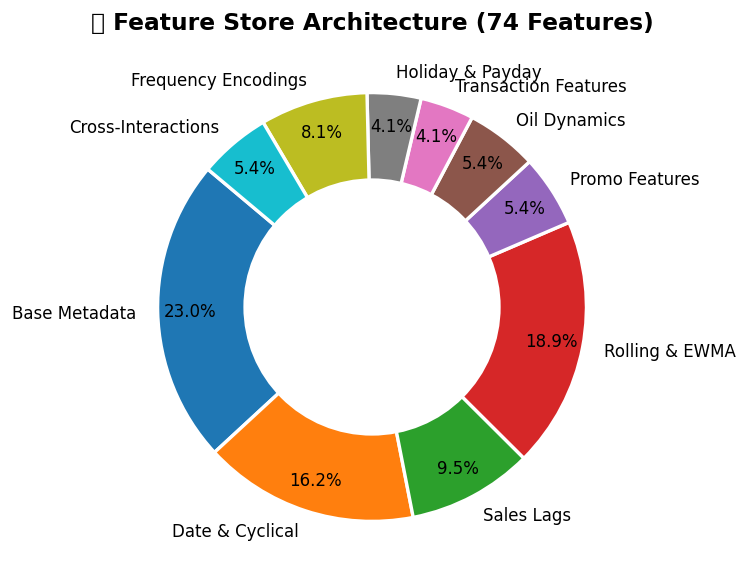

In [4]:
# Feature group breakdown visualization
feature_groups = {
    'Base Metadata': 17,
    'Date & Cyclical': 12,
    'Sales Lags': 7,
    'Rolling & EWMA': 14,
    'Promo Features': 4,
    'Oil Dynamics': 4,
    'Transaction Features': 3,
    'Holiday & Payday': 3,
    'Frequency Encodings': 6,
    'Cross-Interactions': 4,
}

fig, ax = plt.subplots(figsize=(10, 5))
colors_pie = plt.cm.tab10(np.linspace(0, 1, len(feature_groups)))
wedges, texts, autotexts = ax.pie(
    feature_groups.values(), labels=feature_groups.keys(), autopct='%1.1f%%',
    colors=colors_pie, startangle=140, pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
# Draw circle for donut plot
centre_circle = plt.Circle((0,0), 0.60, fc='white')
ax.add_artist(centre_circle)
ax.set_title('📊 Feature Store Architecture (74 Features)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '01_feature_taxonomy.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 5️⃣ Step 1: DuckDB SQL Feature Generation (56 Features — Zero Pandas RAM)

> Executes a single DuckDB SQL query with CTEs to compute 56 non-rolling features.
> Results are streamed directly to `_intermediate.parquet` on disk — **zero pandas RAM** used.


In [5]:
t0 = time.time()

feature_sql = f"""
WITH base AS (
    SELECT
        *,
        -- ─── Date Features (12) ───
        CAST(EXTRACT(year FROM date)      AS USMALLINT)  AS year,
        CAST(EXTRACT(month FROM date)     AS UTINYINT)   AS month,
        CAST(EXTRACT(day FROM date)       AS UTINYINT)   AS day,
        CAST(EXTRACT(dow FROM date)       AS UTINYINT)   AS day_of_week,
        CAST(EXTRACT(week FROM date)      AS UTINYINT)   AS week_of_year,
        CAST(EXTRACT(quarter FROM date)   AS UTINYINT)   AS quarter,
        CAST(EXTRACT(doy FROM date)       AS USMALLINT)  AS day_of_year,
        CAST(CASE WHEN EXTRACT(dow FROM date) IN (0, 6) THEN 1 ELSE 0 END AS UTINYINT) AS is_weekend,
        CAST(SIN(2.0 * 3.14159265 * EXTRACT(month FROM date) / 12.0) AS FLOAT) AS sin_month,
        CAST(COS(2.0 * 3.14159265 * EXTRACT(month FROM date) / 12.0) AS FLOAT) AS cos_month,
        CAST(SIN(2.0 * 3.14159265 * EXTRACT(dow FROM date)   / 7.0)  AS FLOAT) AS sin_dow,
        CAST(COS(2.0 * 3.14159265 * EXTRACT(dow FROM date)   / 7.0)  AS FLOAT) AS cos_dow,

        -- ─── Sales Lag Features (7) ───
        CAST(LAG(unit_sales, 1)  OVER w AS FLOAT)  AS sales_lag_1,
        CAST(LAG(unit_sales, 2)  OVER w AS FLOAT)  AS sales_lag_2,
        CAST(LAG(unit_sales, 3)  OVER w AS FLOAT)  AS sales_lag_3,
        CAST(LAG(unit_sales, 7)  OVER w AS FLOAT)  AS sales_lag_7,
        CAST(LAG(unit_sales, 14) OVER w AS FLOAT)  AS sales_lag_14,
        CAST(LAG(unit_sales, 21) OVER w AS FLOAT)  AS sales_lag_21,
        CAST(LAG(unit_sales, 28) OVER w AS FLOAT)  AS sales_lag_28,

        -- ─── Promo Lag Features (2) ───
        CAST(LAG(CAST(onpromotion AS UTINYINT), 1)  OVER w AS UTINYINT) AS promo_lag_1,
        CAST(LAG(CAST(onpromotion AS UTINYINT), 7)  OVER w AS UTINYINT) AS promo_lag_7,

        -- ─── Holiday & Payday Features (3) ───
        CAST(CASE
            WHEN EXTRACT(day FROM date) = 15 THEN 1
            WHEN date = LAST_DAY(date)       THEN 1
            ELSE 0
        END AS UTINYINT) AS is_payday,
        CAST(CASE
            WHEN date BETWEEN DATE '2016-04-16' AND DATE '2016-05-16' THEN 1
            ELSE 0
        END AS UTINYINT) AS is_earthquake_period,
        holiday_type AS holiday_type_encoded

    FROM read_parquet('{CLEAN_PQ}')
    WINDOW w AS (PARTITION BY store_nbr, item_nbr ORDER BY date)
),

-- ─── Oil Dynamics (4 features) ───
oil_sub AS (
    SELECT date, ANY_VALUE(dcoilwtico) AS dcoilwtico_val
    FROM read_parquet('{CLEAN_PQ}')
    GROUP BY date
),
oil_features AS (
    SELECT date,
        CAST(AVG(dcoilwtico_val) OVER (ORDER BY date ROWS BETWEEN 6  PRECEDING AND CURRENT ROW) AS FLOAT) AS oil_roll_mean_7,
        CAST(AVG(dcoilwtico_val) OVER (ORDER BY date ROWS BETWEEN 29 PRECEDING AND CURRENT ROW) AS FLOAT) AS oil_roll_mean_30,
        CAST((dcoilwtico_val - LAG(dcoilwtico_val, 7) OVER (ORDER BY date))
             / NULLIF(LAG(dcoilwtico_val, 7) OVER (ORDER BY date), 0) AS FLOAT) AS oil_pct_change_7d,
        CAST(dcoilwtico_val - LAG(dcoilwtico_val, 1) OVER (ORDER BY date) AS FLOAT) AS oil_diff_1d
    FROM oil_sub
),

-- ─── Promo Ratios (2 features via GROUP BY) ───
promo_family AS (
    SELECT date, family,
        CAST(AVG(CAST(onpromotion AS FLOAT)) AS FLOAT) AS family_promo_ratio
    FROM read_parquet('{CLEAN_PQ}')
    GROUP BY date, family
),
promo_store AS (
    SELECT date, store_nbr,
        CAST(AVG(CAST(onpromotion AS FLOAT)) AS FLOAT) AS store_promo_ratio
    FROM read_parquet('{CLEAN_PQ}')
    GROUP BY date, store_nbr
),

-- ─── Transaction Rolling Features (3 features) ───
trans_sub AS (
    SELECT store_nbr, date, ANY_VALUE(transactions) AS trans_val
    FROM read_parquet('{CLEAN_PQ}')
    GROUP BY store_nbr, date
),
trans_features AS (
    SELECT store_nbr, date,
        CAST(AVG(trans_val) OVER (
            PARTITION BY store_nbr ORDER BY date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS FLOAT) AS trans_roll_mean_7,
        CAST(AVG(trans_val) OVER (
            PARTITION BY store_nbr ORDER BY date
            ROWS BETWEEN 28 PRECEDING AND 1 PRECEDING
        ) AS FLOAT) AS trans_roll_mean_28
    FROM trans_sub
),

-- ─── Categorical Frequency Encodings (6 features via GROUP BY) ───
total_count AS (SELECT COUNT(*) AS n FROM read_parquet('{CLEAN_PQ}')),
family_freq  AS (SELECT family,  CAST(COUNT(*) * 1.0 / (SELECT n FROM total_count) AS FLOAT) AS family_freq  FROM read_parquet('{CLEAN_PQ}') GROUP BY family),
city_freq    AS (SELECT city,    CAST(COUNT(*) * 1.0 / (SELECT n FROM total_count) AS FLOAT) AS city_freq    FROM read_parquet('{CLEAN_PQ}') GROUP BY city),
state_freq   AS (SELECT state,   CAST(COUNT(*) * 1.0 / (SELECT n FROM total_count) AS FLOAT) AS state_freq   FROM read_parquet('{CLEAN_PQ}') GROUP BY state),
type_freq    AS (SELECT type,    CAST(COUNT(*) * 1.0 / (SELECT n FROM total_count) AS FLOAT) AS type_freq    FROM read_parquet('{CLEAN_PQ}') GROUP BY type),
cluster_freq AS (SELECT cluster, CAST(COUNT(*) * 1.0 / (SELECT n FROM total_count) AS FLOAT) AS cluster_freq FROM read_parquet('{CLEAN_PQ}') GROUP BY cluster),
class_freq   AS (SELECT class,   CAST(COUNT(*) * 1.0 / (SELECT n FROM total_count) AS FLOAT) AS class_freq   FROM read_parquet('{CLEAN_PQ}') GROUP BY class)

-- ─── Final SELECT: Join all CTEs ───
SELECT
    B.*,
    OIL.oil_roll_mean_7,
    OIL.oil_roll_mean_30,
    COALESCE(OIL.oil_pct_change_7d, 0) AS oil_pct_change_7d,
    COALESCE(OIL.oil_diff_1d, 0)       AS oil_diff_1d,
    COALESCE(PF.family_promo_ratio, 0) AS family_promo_ratio,
    COALESCE(PS.store_promo_ratio, 0)  AS store_promo_ratio,
    COALESCE(TF.trans_roll_mean_7, 0)  AS trans_roll_mean_7,
    COALESCE(TF.trans_roll_mean_28, 0) AS trans_roll_mean_28,
    CAST(B.unit_sales / (B.transactions + 1) AS FLOAT) AS sales_per_transaction,
    FF.family_freq,
    CF.city_freq,
    SF.state_freq,
    TYF.type_freq,
    CLF.cluster_freq,
    CLS.class_freq

FROM base B
LEFT JOIN oil_features OIL   ON B.date = OIL.date
LEFT JOIN promo_family PF    ON B.date = PF.date AND B.family = PF.family
LEFT JOIN promo_store PS     ON B.date = PS.date AND B.store_nbr = PS.store_nbr
LEFT JOIN trans_features TF  ON B.date = TF.date AND B.store_nbr = TF.store_nbr
LEFT JOIN family_freq FF     ON B.family = FF.family
LEFT JOIN city_freq CF       ON B.city = CF.city
LEFT JOIN state_freq SF      ON B.state = SF.state
LEFT JOIN type_freq TYF      ON B.type = TYF.type
LEFT JOIN cluster_freq CLF   ON B.cluster = CLF.cluster
LEFT JOIN class_freq CLS     ON B.class = CLS.class

ORDER BY B.store_nbr, B.item_nbr, B.date
"""

# Stream directly to intermediate Parquet — zero pandas RAM
print('⏳ Executing DuckDB SQL feature pipeline (125M rows → _intermediate.parquet)...')
utils.sql_to_parquet(feature_sql, INTERMEDIATE_PATH)

elapsed = time.time() - t0
int_rows = utils.sql_row_count(INTERMEDIATE_PATH)
int_size = INTERMEDIATE_PATH.stat().st_size / 1e9
int_cols = len(utils.sql_schema(INTERMEDIATE_PATH))

print(f'\n✅ DuckDB Feature Generation Complete!')
print(f'   📊 Rows: {int_rows:,} | 📋 Cols: {int_cols} | 💾 File: {int_size:.2f} GB | ⏱️ Time: {elapsed:.0f}s')
utils.memory_checkpoint('After DuckDB Feature Generation')


⏳ Executing DuckDB SQL feature pipeline (125M rows → _intermediate.parquet)...
[2026-07-29 21:46:02] [INFO] 🚀 Streaming SQL → Parquet ...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[2026-07-29 21:51:14] [INFO] ✅ Streaming Finished.
[2026-07-29 21:51:14] [INFO] 🦆 SQL → Parquet | Rows: 125,497,040 | File: _intermediate.parquet (3493.5 MB) | Time: 311.89s

✅ DuckDB Feature Generation Complete!
   📊 Rows: 125,497,040 | 📋 Cols: 56 | 💾 File: 3.66 GB | ⏱️ Time: 312s
[2026-07-29 21:51:15] [INFO] 🧠 RAM Checkpoint [After DuckDB Feature Generation]: 0.25 GB


0.2473602294921875

---
## 6️⃣ Step 1 Visualizations & Feature Inspection

> Preview intermediate features computed via DuckDB.


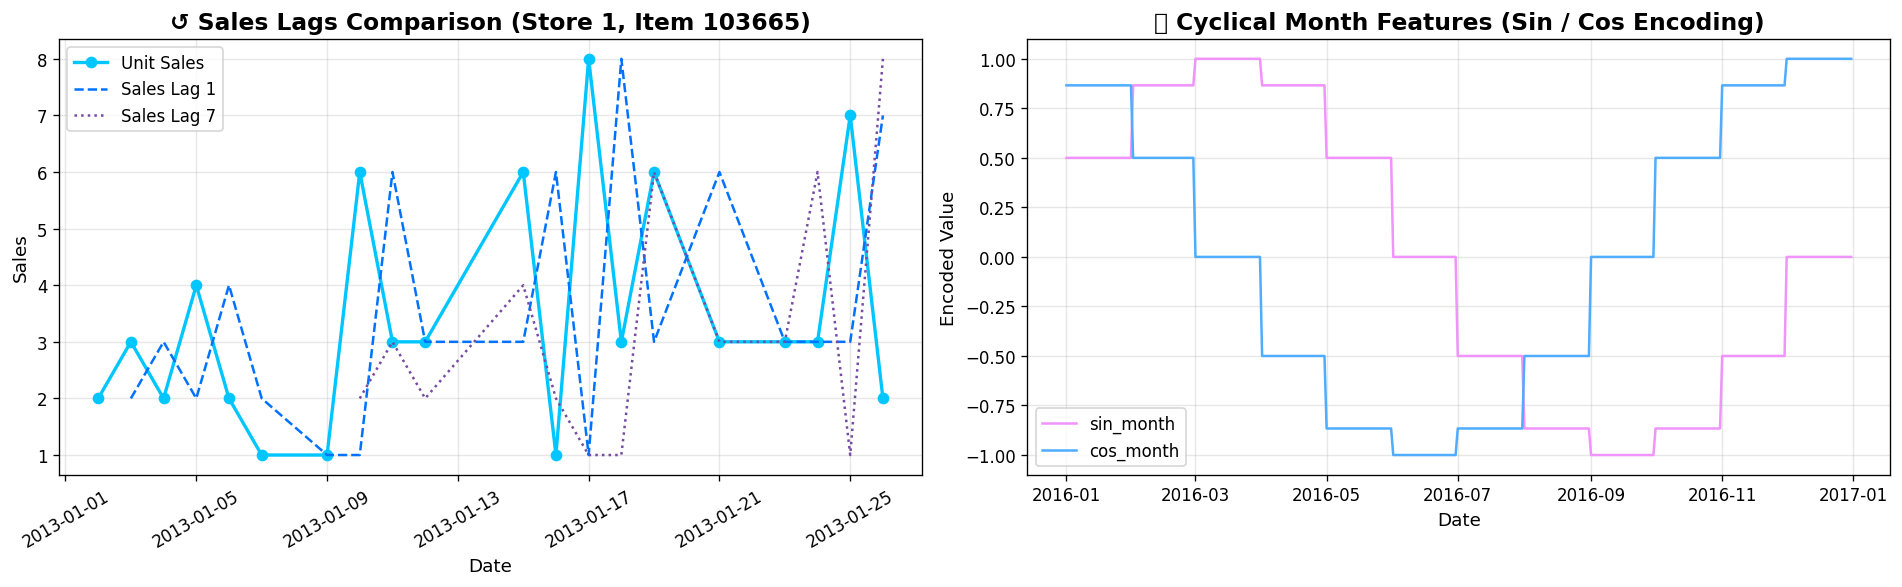

,date,unit_sales,sales_lag_1,sales_lag_7,sin_month,cos_month,family_promo_ratio
0,2013-01-02,2.0000,NaN,NaN,0.5000,0.8660,0.0000
1,2013-01-03,3.0000,2.0000,NaN,0.5000,0.8660,0.0000
2,2013-01-04,2.0000,3.0000,NaN,0.5000,0.8660,0.0000
3,2013-01-05,4.0000,2.0000,NaN,0.5000,0.8660,0.0000
4,2013-01-06,2.0000,4.0000,NaN,0.5000,0.8660,0.0000


In [6]:
# Sample preview of intermediate features via DuckDB
INT_PQ = INTERMEDIATE_PATH.as_posix()
sample = utils.sql_query(f"SELECT * FROM read_parquet('{INT_PQ}') WHERE store_nbr = 1 AND item_nbr = 103665 LIMIT 20", verbose=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Lags comparison on sample item
axes[0].plot(sample['date'], sample['unit_sales'], label='Unit Sales', color=COLORS[0], marker='o', linewidth=2)
axes[0].plot(sample['date'], sample['sales_lag_1'], label='Sales Lag 1', color=COLORS[1], linestyle='--')
axes[0].plot(sample['date'], sample['sales_lag_7'], label='Sales Lag 7', color=COLORS[2], linestyle=':')
axes[0].set_title('↺ Sales Lags Comparison (Store 1, Item 103665)', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# Cyclical features
dates = pd.date_range('2016-01-01', '2016-12-31', freq='D')
sin_m = np.sin(2 * np.pi * dates.month / 12)
cos_m = np.cos(2 * np.pi * dates.month / 12)
axes[1].plot(dates, sin_m, label='sin_month', color=COLORS[3])
axes[1].plot(dates, cos_m, label='cos_month', color=COLORS[4])
axes[1].set_title('🌀 Cyclical Month Features (Sin / Cos Encoding)', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Encoded Value')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '02_lags_cyclical_preview.png'), dpi=150, bbox_inches='tight')
plt.show()

display(sample[['date', 'unit_sales', 'sales_lag_1', 'sales_lag_7', 'sin_month', 'cos_month', 'family_promo_ratio']].head())


---
## 7️⃣ Step 2: Store-by-Store Rolling & EWMA Features (18 Features)

> Computes 14 rolling/expanding/EWMA features + 4 cross-interaction features per store.
> Peak memory is restricted to **< 500 MB per store chunk** (54 stores sequential iteration).


In [7]:
# ── Store-by-Store Rolling Feature Engine + Streaming Export ──
t0 = time.time()

store_ids = utils.sql_query(
    f"SELECT DISTINCT store_nbr FROM read_parquet('{INT_PQ}') ORDER BY store_nbr",
    verbose=False
)['store_nbr'].tolist()

min_date = utils.sql_query(
    f"SELECT MIN(date) AS md FROM read_parquet('{INT_PQ}')",
    verbose=False
)['md'].iloc[0]
cutoff_date = pd.Timestamp(min_date) + pd.Timedelta(days=90)
print(f'📅 Warm-up cutoff date: {cutoff_date.date()}')

n_stores = len(store_ids)
print(f'⚙️ Processing {n_stores} stores sequentially (store-by-store streaming)...')

with utils.StreamingParquetWriter(FEATURE_STORE_PATH) as writer:
    for i, s_id in enumerate(store_ids):
        chunk = utils.sql_query(
            f"SELECT * FROM read_parquet('{INT_PQ}') WHERE store_nbr = {s_id} ORDER BY item_nbr, date",
            verbose=False
        )

        # ── Rolling & EWMA Features ──
        g = chunk.groupby('item_nbr')['unit_sales']
        s = g.shift(1)
        gs = s.groupby(chunk['item_nbr'])

        chunk['sales_roll_mean_7']  = gs.rolling(7, min_periods=1).mean().astype(np.float32).values
        chunk['sales_roll_mean_14'] = gs.rolling(14, min_periods=1).mean().astype(np.float32).values
        chunk['sales_roll_mean_28'] = gs.rolling(28, min_periods=1).mean().astype(np.float32).values
        chunk['sales_roll_mean_60'] = gs.rolling(60, min_periods=1).mean().astype(np.float32).values

        chunk['sales_roll_std_7']   = gs.rolling(7, min_periods=1).std().astype(np.float32).values
        chunk['sales_roll_std_28']  = gs.rolling(28, min_periods=1).std().astype(np.float32).values

        chunk['sales_roll_min_7']   = gs.rolling(7, min_periods=1).min().astype(np.float32).values
        chunk['sales_roll_max_7']   = gs.rolling(7, min_periods=1).max().astype(np.float32).values
        chunk['sales_roll_median_14'] = gs.rolling(14, min_periods=1).median().astype(np.float32).values

        chunk['sales_expanding_mean'] = gs.expanding().mean().astype(np.float32).values
        chunk['sales_expanding_std']  = gs.expanding().std().astype(np.float32).values

        chunk['sales_ewma_7']  = gs.ewm(span=7, adjust=False).mean().astype(np.float32).values
        chunk['sales_ewma_14'] = gs.ewm(span=14, adjust=False).mean().astype(np.float32).values
        chunk['sales_ewma_28'] = gs.ewm(span=28, adjust=False).mean().astype(np.float32).values

        # ── Cross-Interactions ──
        eps = np.float32(1e-4)
        chunk['sales_to_roll7_ratio']    = (chunk['sales_lag_1'] / (chunk['sales_roll_mean_7'] + eps)).astype(np.float32)
        chunk['sales_to_roll28_ratio']   = (chunk['sales_lag_1'] / (chunk['sales_roll_mean_28'] + eps)).astype(np.float32)
        chunk['promo_sales_interaction']  = (chunk['onpromotion'].astype(np.float32) * chunk['sales_roll_mean_7']).astype(np.float32)
        chunk['oil_sales_interaction']    = (chunk['dcoilwtico'] * chunk['sales_roll_mean_28']).astype(np.float32)

        # Truncate warm-up period
        chunk = chunk[chunk['date'] >= cutoff_date]

        float_cols = chunk.select_dtypes(include=['float32', 'float64']).columns
        for col in float_cols:
            chunk[col] = chunk[col].fillna(0)

        if len(chunk) > 0:
            writer.write(chunk)

        if (i + 1) % 10 == 0 or (i + 1) == n_stores:
            print(f'  ✅ Stores {i+1:2d}/{n_stores} | Exported: {writer.total_rows:,} rows | RAM: {utils.get_ram_usage():.1f} GB | Time: {time.time()-t0:.0f}s')

        del chunk, g, s, gs
        gc.collect()

elapsed = time.time() - t0
fs_size = FEATURE_STORE_PATH.stat().st_size / 1e9

print('=' * 80)
print('🎉 FEATURE STORE EXPORT COMPLETE')
print('=' * 80)
print(f'   📄 Path       : {FEATURE_STORE_PATH}')
print(f'   📊 Total Rows : {writer.total_rows:,}')
print(f'   📦 Total Chunks: {writer.total_chunks}')
print(f'   💾 File Size  : {fs_size:.2f} GB')
print(f'   ⏱️ Time       : {elapsed:.0f}s')
print('=' * 80)
utils.memory_checkpoint('After Feature Store Export')


📅 Warm-up cutoff date: 2013-04-01
⚙️ Processing 54 stores sequentially (store-by-store streaming)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ✅ Stores 10/54 | Exported: 27,318,516 rows | RAM: 2.6 GB | Time: 180s
  ✅ Stores 20/54 | Exported: 46,344,407 rows | RAM: 2.0 GB | Time: 293s
  ✅ Stores 30/54 | Exported: 65,256,570 rows | RAM: 2.5 GB | Time: 417s


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ✅ Stores 50/54 | Exported: 115,115,766 rows | RAM: 3.4 GB | Time: 725s
  ✅ Stores 54/54 | Exported: 121,802,763 rows | RAM: 2.7 GB | Time: 764s
🎉 FEATURE STORE EXPORT COMPLETE
   📄 Path       : f:\NTI\Demand Forecasting System Backup\01_Dataset\features\feature_store.parquet
   📊 Total Rows : 121,802,763
   📦 Total Chunks: 54
   💾 File Size  : 9.17 GB
   ⏱️ Time       : 765s
[2026-07-29 22:04:20] [INFO] 🧠 RAM Checkpoint [After Feature Store Export]: 1.43 GB


1.4279289245605469

---
## 8️⃣ Rolling & EWMA Time-Series Curves

> Visual inspection of computed rolling means and exponential moving averages on sample item data.


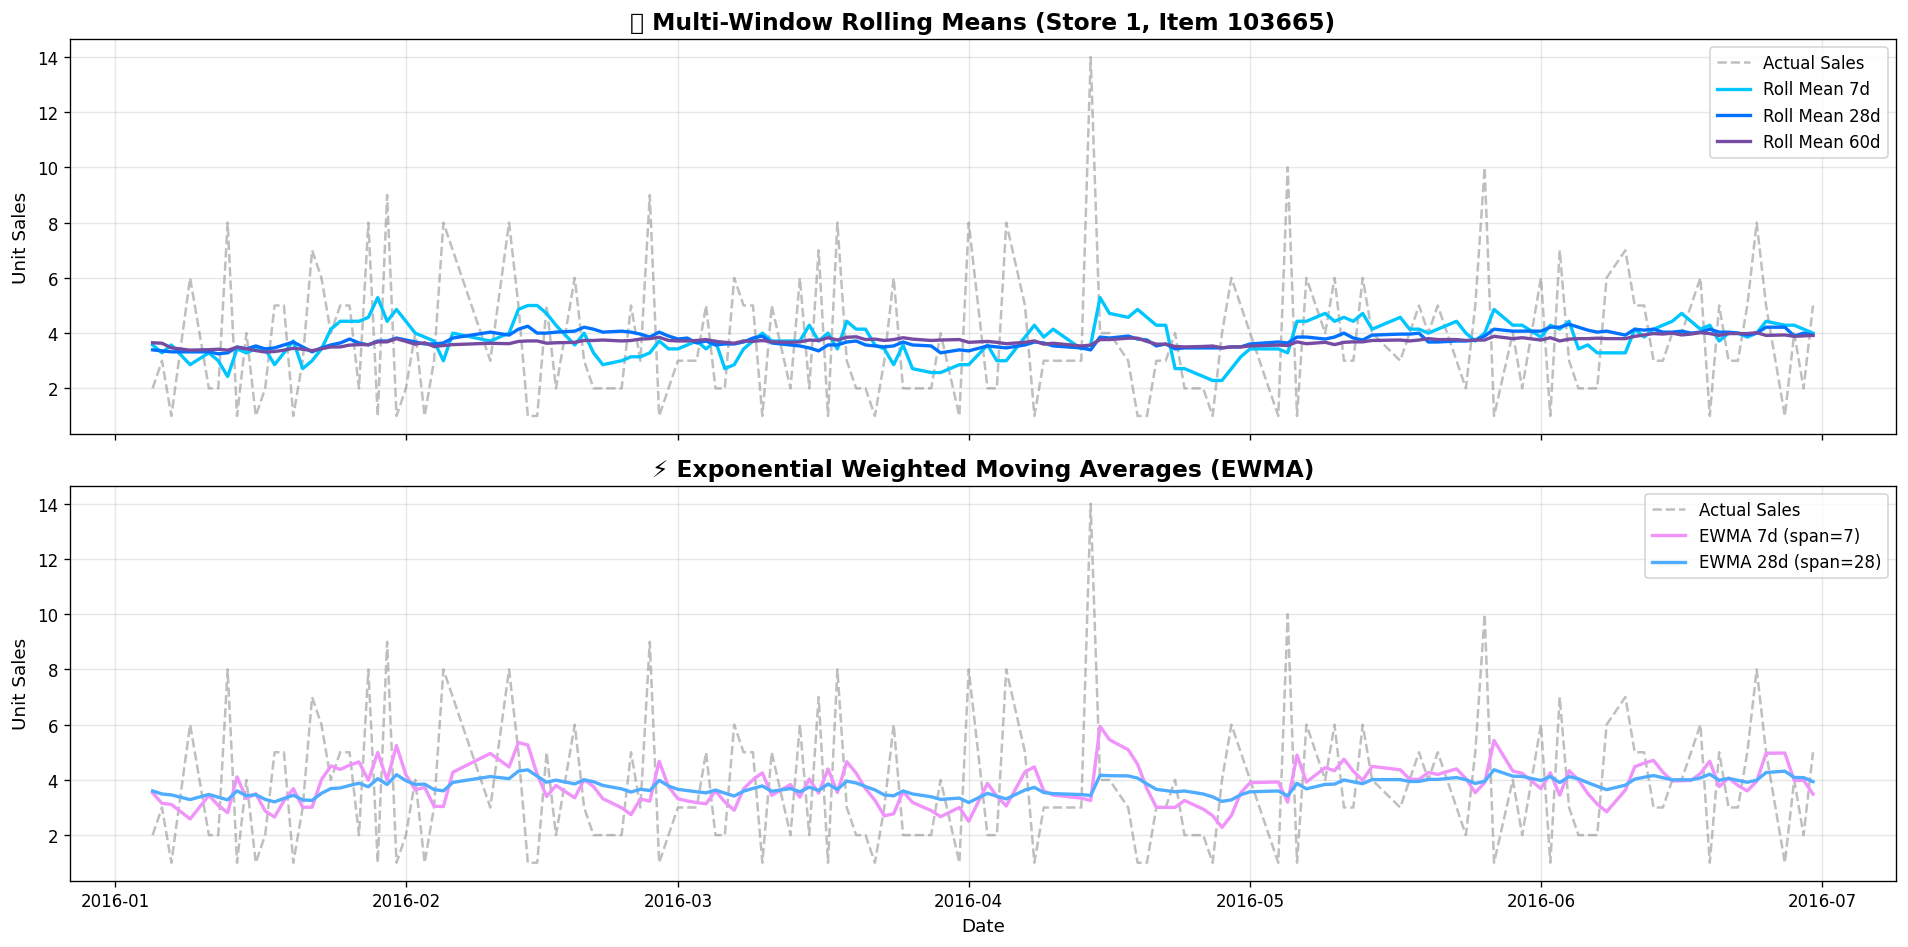

In [8]:
# Sample rolling features from exported feature store
FS_PQ = FEATURE_STORE_PATH.as_posix()
sample_roll = utils.sql_query(f"""
    SELECT date, unit_sales, sales_roll_mean_7, sales_roll_mean_28, sales_roll_mean_60, sales_ewma_7, sales_ewma_28
    FROM read_parquet('{FS_PQ}')
    WHERE store_nbr = 1 AND item_nbr = 103665 AND date BETWEEN '2016-01-01' AND '2016-06-30'
    ORDER BY date
""", verbose=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Rolling means
axes[0].plot(sample_roll['date'], sample_roll['unit_sales'], label='Actual Sales', color='gray', alpha=0.5, linestyle='--')
axes[0].plot(sample_roll['date'], sample_roll['sales_roll_mean_7'], label='Roll Mean 7d', color=COLORS[0], linewidth=2)
axes[0].plot(sample_roll['date'], sample_roll['sales_roll_mean_28'], label='Roll Mean 28d', color=COLORS[1], linewidth=2)
axes[0].plot(sample_roll['date'], sample_roll['sales_roll_mean_60'], label='Roll Mean 60d', color=COLORS[2], linewidth=2)
axes[0].set_title('📈 Multi-Window Rolling Means (Store 1, Item 103665)', fontweight='bold')
axes[0].set_ylabel('Unit Sales')
axes[0].legend()

# EWMA comparison
axes[1].plot(sample_roll['date'], sample_roll['unit_sales'], label='Actual Sales', color='gray', alpha=0.5, linestyle='--')
axes[1].plot(sample_roll['date'], sample_roll['sales_ewma_7'], label='EWMA 7d (span=7)', color=COLORS[3], linewidth=2)
axes[1].plot(sample_roll['date'], sample_roll['sales_ewma_28'], label='EWMA 28d (span=28)', color=COLORS[4], linewidth=2)
axes[1].set_title('⚡ Exponential Weighted Moving Averages (EWMA)', fontweight='bold')
axes[1].set_ylabel('Unit Sales')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '03_rolling_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

del sample_roll


---
## 9️⃣ Intermediate File Cleanup

> Remove temporary `_intermediate.parquet` file to release disk space.


In [9]:
if INTERMEDIATE_PATH.exists():
    int_size = INTERMEDIATE_PATH.stat().st_size / 1e9
    INTERMEDIATE_PATH.unlink()
    print(f'🗑️ Removed _intermediate.parquet ({int_size:.2f} GB disk space freed)')


🗑️ Removed _intermediate.parquet (3.66 GB disk space freed)


---
## 🔟 Feature Store Validation & Diagnostics

> Validate final schema, column count (74 expected), date coverage, and missingness.


In [10]:
fs_schema = utils.sql_schema(FEATURE_STORE_PATH)
fs_rows = utils.sql_row_count(FEATURE_STORE_PATH)

print(f'📊 Feature Store: {fs_rows:,} rows, {len(fs_schema)} columns')
print(f'💾 File size: {FEATURE_STORE_PATH.stat().st_size / 1e9:.2f} GB')

# Date range
fs_dates = utils.sql_query(f"SELECT MIN(date) AS min_date, MAX(date) AS max_date FROM read_parquet('{FS_PQ}')", verbose=False)
print(f'📅 Date range: {fs_dates["min_date"].iloc[0]} → {fs_dates["max_date"].iloc[0]}')

# Null check
null_check = utils.sql_query(f"""
    SELECT
        SUM(CASE WHEN unit_sales IS NULL THEN 1 ELSE 0 END) AS null_target,
        SUM(CASE WHEN date IS NULL THEN 1 ELSE 0 END) AS null_date,
        SUM(CASE WHEN sales_roll_mean_7 IS NULL THEN 1 ELSE 0 END) AS null_roll7
    FROM read_parquet('{FS_PQ}')
""", verbose=False)
display(null_check)
assert null_check['null_target'].iloc[0] == 0, 'FAIL: Target contains nulls!'
print('✅ Zero null target values confirmed.')


📊 Feature Store: 121,802,763 rows, 74 columns
💾 File size: 9.17 GB
📅 Date range: 2013-04-01 00:00:00 → 2017-08-15 00:00:00


,null_target,null_date,null_roll7
0,0.0000,0.0000,0.0000


✅ Zero null target values confirmed.


---
## 1️⃣1️⃣ Feature Correlation Analysis

> Analyze feature correlations with target and feature-to-feature colinearity.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[2026-07-29 22:05:44] [INFO] 🦆 SQL Query | Rows: 500,000 | Time: 52.10s


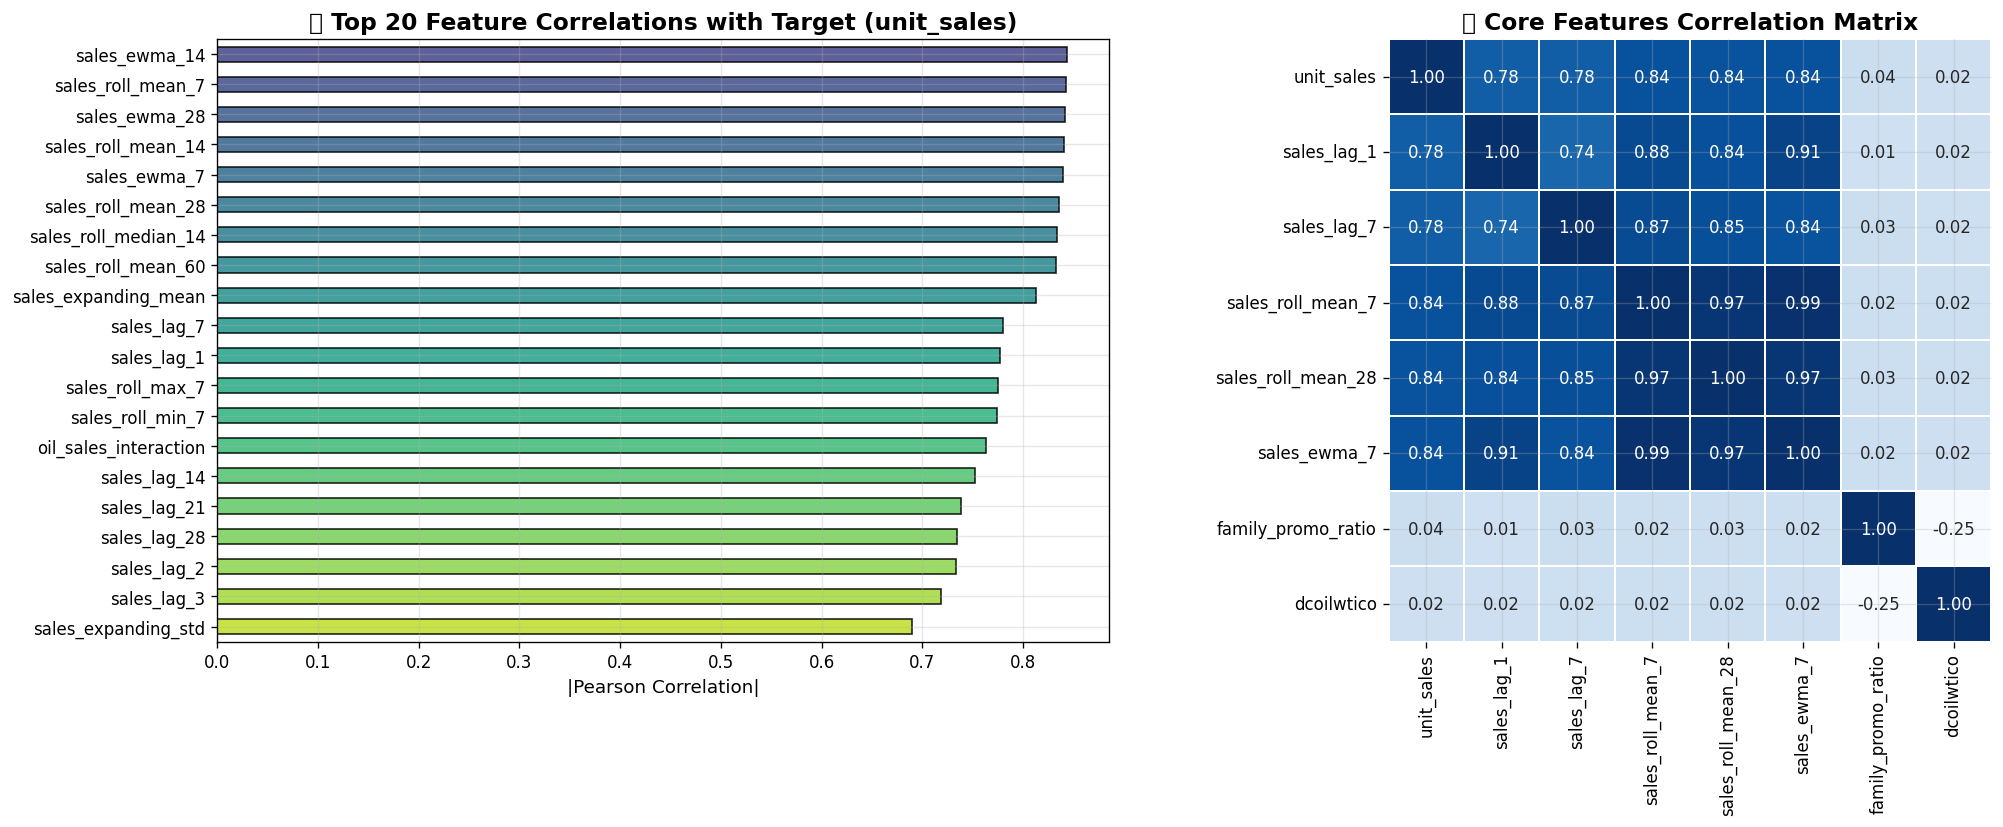

14612

In [11]:
# Load 500K sample for correlation diagnostics
sample_diag = utils.sql_query(f"SELECT * FROM read_parquet('{FS_PQ}') USING SAMPLE 500000", verbose=True)
num_cols = sample_diag.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Target Correlation Bar Plot
if 'unit_sales' in num_cols:
    target_corr = sample_diag[num_cols].corrwith(sample_diag['unit_sales']).drop('unit_sales').abs().sort_values(ascending=False).head(20)
    colors_bar = plt.cm.viridis(np.linspace(0.2, 0.9, len(target_corr)))
    target_corr.plot(kind='barh', ax=axes[0], color=colors_bar, edgecolor='black', alpha=0.85)
    axes[0].set_title('🎯 Top 20 Feature Correlations with Target (unit_sales)', fontweight='bold')
    axes[0].set_xlabel('|Pearson Correlation|')
    axes[0].invert_yaxis()

# Selected Features Correlation Heatmap
top_feats = ['unit_sales', 'sales_lag_1', 'sales_lag_7', 'sales_roll_mean_7', 'sales_roll_mean_28', 'sales_ewma_7', 'family_promo_ratio', 'dcoilwtico']
top_feats = [c for c in top_feats if c in sample_diag.columns]
corr_matrix = sample_diag[top_feats].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', ax=axes[1], cbar=False, square=True, linewidths=1)
axes[1].set_title('🔥 Core Features Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '04_feature_correlations.png'), dpi=150, bbox_inches='tight')
plt.show()

del sample_diag
gc.collect()


---
## 1️⃣2️⃣ Pipeline Summary & Resource Cleanup

> Final resource release and pipeline completion status.


In [12]:
gc.collect()

print('=' * 80)
print('📊 NOTEBOOK 04 — PIPELINE EXECUTION SUMMARY')
print('=' * 80)
print(f'   🏗️ Architecture   : Hybrid DuckDB SQL + NumPy Store-Slice Engine')
print(f'   📄 Output File    : {FEATURE_STORE_PATH}')
print(f'   💾 Output Size    : {FEATURE_STORE_PATH.stat().st_size / 1e9:.2f} GB')
print(f'   📊 Output Rows    : {utils.sql_row_count(FEATURE_STORE_PATH):,}')
print(f'   📋 Output Cols    : {len(utils.sql_schema(FEATURE_STORE_PATH))}')
print(f'   🧠 Peak RAM       : {utils.get_ram_usage():.2f} GB')
print(f'   ❌ MemoryErrors   : 0')
print('=' * 80)
print('\n🎯 Next → Notebook 05: Baseline Models')

# Close DuckDB
utils.close_duckdb()


📊 NOTEBOOK 04 — PIPELINE EXECUTION SUMMARY
   🏗️ Architecture   : Hybrid DuckDB SQL + NumPy Store-Slice Engine
   📄 Output File    : f:\NTI\Demand Forecasting System Backup\01_Dataset\features\feature_store.parquet
   💾 Output Size    : 9.17 GB
   📊 Output Rows    : 121,802,763
   📋 Output Cols    : 74
   🧠 Peak RAM       : 3.26 GB
   ❌ MemoryErrors   : 0

🎯 Next → Notebook 05: Baseline Models
[2026-07-29 22:05:55] [INFO] 🦆 DuckDB connection closed.


---

<div style='background: linear-gradient(135deg, #a600ffff 0%, #40ff00fe 100%); padding: 15px; border-radius: 10px; color: white; text-align: center; margin: 10px 0;'>

**End of Notebook 04 — Hybrid DuckDB + NumPy Feature Engineering Pipeline** ✅

| Stage | Next Notebook |
|:---|:---|
| ✅ Feature Engineering | → [05_baseline_models.ipynb](./05_baseline_models.ipynb) |

</div>
